# Hydrological Simulation with CATHY — Long-Term Hydrology

**GRwater project**

This notebook runs a long-term (LT) subsurface hydrology simulation using the **pyCATHY** framework. It covers the full pipeline:

1. Loading ERA5 climate forcing data
2. Logging simulation parameters
3. Extracting point time-series for the Agramon study site
4. Initialising and meshing the CATHY model from a DEM
5. Running the CATHY preprocessor and processor

> ⏱ *Estimated runtime: ~5 minutes*

---
## 1. Imports

We import standard scientific Python libraries (`numpy`, `pandas`, `matplotlib`) together with:
- **rioxarray / xarray** — for reading and manipulating geospatial raster data (the DEM and ERA5 NetCDF files)
- **Agramon_utils (AgUtils)** — a project-specific utility module that handles ERA5 loading, shapefile reading, and time-series extraction
- **pyCATHY** — the Python interface to the CATHY subsurface hydrological model

The `module_path` block ensures the custom utility module can be found even when the notebook is run from a different working directory.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt
import sys
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython.display import display

# Add the path where Agramon_utils.py and uCATHY.py are located
module_path = Path('../../GRwater_geophy').resolve()  # ← update if needed
if str(module_path) not in sys.path:
    sys.path.append(str(module_path))

import Agramon_utils as AgUtils
import geoutils
from geoutils import uCATHY
from pyCATHY import cathy_tools

Install emagpy if needed
Install pygimli if needed
Install emagpy if needed


The Agramon study area is defined by polygon shapefiles. `AgUtils.load_plot_shapefiles()` reads all shapefiles from the designated folder into a **GeoDataFrame**.

In [3]:
import leafmap
gdf_Agramon = AgUtils.load_plot_shapefiles(module_path / 'shapefiles')
# Compute bounding box from the GeoDataFrame [minx, miny, maxx, maxy]
bbox = gdf_Agramon.total_bounds  # returns [west, south, east, north]
m = leafmap.Map()
# Add satellite ("earth view") basemap — removes default OSM first
m.add_basemap("Esri.WorldImagery")
# Add the GDF layer
m.add_gdf(gdf_Agramon, layer_name="Agramon", zoom_to_layer=True)
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

---
## 9. Load and Pre-process the Digital Elevation Model (DEM)

The DEM defines the topography of the simulation domain. Here we use an **ArcInfo ASCII Grid (.adf)** raster stored in a folder. The processing steps are:

1. **Open** the raster with `rioxarray` and drop the band dimension (single-band DEM)
2. **Mask** the data — identify the bounding box of valid (non-NaN) pixels to crop out any NoData border
3. **Replace NaN** with -9999 — the CATHY convention for missing/outside-domain cells

The spatial resolution is set to **5 m × 5 m** (`delta_x`, `delta_y`) and `ivert=1` activates vertical coordinate inversion (z positive upward).

In [11]:
import ipywidgets as widgets
from IPython.display import display

w_adf_folder = widgets.Dropdown(
    options=[f"../prepro/DTMsPlota/dtmplot{i}/" for i in range(1, 7)],
    value="../prepro/DTMsPlota/dtmplot4/",
    description="DEM folder:",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="340px")
)

display(w_adf_folder)

Dropdown(description='DEM folder:', index=3, layout=Layout(width='340px'), options=('../prepro/DTMsPlota/dtmpl…

In [13]:
# Path to the folder containing the .adf raster files
adf_folder = w_adf_folder.value

# Open raster and select first (and only) band
raster_DEM = rxr.open_rasterio(adf_folder, masked=True).isel(band=0)

# ── Crop to valid-data bounding box ──────────────────────────────────────────
valid_mask = ~np.isnan(raster_DEM)
valid_x = raster_DEM['x'].where(valid_mask.any(dim='y'), drop=True)
valid_y = raster_DEM['y'].where(valid_mask.any(dim='x'), drop=True)

min_lon, max_lon = float(valid_x.min()), float(valid_x.max())
min_lat, max_lat = float(valid_y.min()), float(valid_y.max())

raster_DEM_masked = (
    raster_DEM
    .where((raster_DEM['x'] >= min_lon) & (raster_DEM['x'] <= max_lon), drop=True)
    .where((raster_DEM['y'] >= min_lat) & (raster_DEM['y'] <= max_lat), drop=True)
)

# Replace NaN → -9999 (CATHY no-data convention)
raster_DEM_masked = np.where(np.isnan(raster_DEM_masked), -9999, raster_DEM_masked)

print(f"Original DEM shape : {np.shape(raster_DEM)}")
print(f"Masked DEM shape   : {np.shape(raster_DEM_masked)}")

Original DEM shape : (161, 283)
Masked DEM shape   : (35, 61)


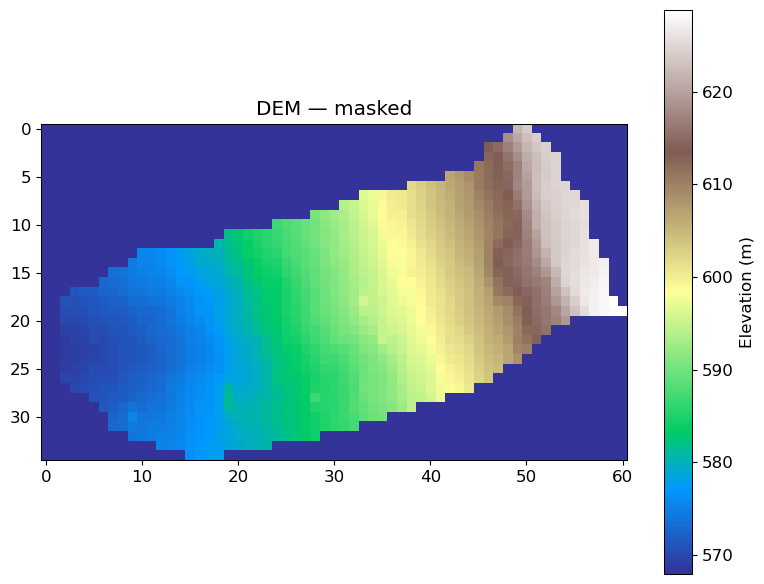

In [17]:
# 2-D elevation map
vmax = np.nanmax(raster_DEM_masked[raster_DEM_masked != -9999])
vmin = np.nanmin(raster_DEM_masked[raster_DEM_masked != -9999])

fig, ax = plt.subplots(1, figsize=(8, 6))
img = ax.imshow(raster_DEM_masked, cmap='terrain', vmin=vmin, vmax=vmax)
plt.colorbar(img, ax=ax, label='Elevation (m)')
ax.set_title('DEM — masked')
plt.tight_layout()
plt.show()

---
## 2. Simulation Parameters

Use the interactive widgets below to configure the simulation. Values are read from the widgets later when building the `params` dict.

| Parameter | Description | Default |
|-----------|-------------|--------|
| `start_year` | First year of ERA5 forcing to load | 2011 |
| `end_year` | Last year (exclusive upper bound) | 2012 |
| `ZROOT` | Root depth (m) used in the soil vegetation file | 1.0 |
| `PMIN` | Minimum pressure head threshold (m) for the soil model | -5 |
| `log_file` | Path to the CSV file used to track simulation runs | `simulation_log.csv` |

In [4]:
w_start_year = widgets.BoundedIntText(
    value=2011, min=1990, max=2030, step=1,
    description='start_year:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='280px')
)

w_end_year = widgets.BoundedIntText(
    value=2012, min=1990, max=2031, step=1,
    description='end_year:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='280px')
)

w_ZROOT = widgets.BoundedFloatText(
    value=1.0, min=0.1, max=10.0, step=0.1,
    description='ZROOT (m):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='280px')
)

w_PMIN = widgets.BoundedFloatText(
    value=-5.0, min=-100.0, max=0.0, step=0.5,
    description='PMIN (m):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='280px')
)

w_log_file = widgets.Text(
    value='simulation_log.csv',
    description='log_file:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='380px')
)

box = widgets.VBox([
    widgets.HTML('<b>── Simulation Parameters ──</b>'),
    w_start_year, w_end_year, w_ZROOT, w_PMIN, w_log_file
])
display(box)

---
## 3. Read Widget Values

After adjusting the widgets above, run this cell to capture the current values into plain Python variables used throughout the rest of the notebook.

In [ ]:
# Read values from widgets
start_year = w_start_year.value
end_year   = w_end_year.value
ZROOT      = w_ZROOT.value
PMIN       = w_PMIN.value
log_file   = w_log_file.value

print(f"start_year : {start_year}")
print(f"end_year   : {end_year}  (ERA5 loaded up to {end_year - 1})")
print(f"ZROOT      : {ZROOT} m")
print(f"PMIN       : {PMIN} m")
print(f"log_file   : {log_file}")

---
## 4. Load ERA5 Climate Forcing Data

ERA5 reanalysis data (from ECMWF) provides the meteorological forcing for the simulation. The `AgUtils.load_era5_series()` helper reads pre-downloaded ERA5 NetCDF files for the requested year range and returns an **xarray Dataset** containing variables such as:
- `tp` — total precipitation (m)
- `pev` — potential evapotranspiration (m)

The root path is assumed to be one level above the current working directory.

In [ ]:
rootPath = Path('..').resolve()

ds = AgUtils.load_era5_series(
    root_path=rootPath,
    start_year=start_year,
    end_year=end_year
)

if ds is not None:
    print(f"Loaded ERA5 dataset from {start_year} to {end_year - 1}")
    print(ds)
else:
    print("No datasets loaded — check your rootPath and ERA5 file locations.")

---
## 5. Log This Simulation Run

Before doing any heavy computation we register the current parameter set using `uCATHY.log_simulation()`. The returned `sim_index` is embedded in the project folder name later, allowing outputs to be unambiguously traced back to their configuration.

The function writes (or updates) a CSV log file that records:
- A unique `sim_index` for each distinct parameter combination
- The `datetime` of the most recent run
- All simulation parameters

If you re-run with the **same parameters**, the existing `sim_index` is reused — no duplicate rows are created.

In [ ]:
params = {
    "start_year": start_year,
    "end_year":   end_year,
    "ZROOT":      ZROOT,
    "PMIN":       PMIN,
}

# uCATHY.log_simulation handles CSV tracking: reuses sim_index for duplicate
# parameter sets, or creates a new numbered entry for novel configurations.
sim_index = uCATHY.log_simulation(log_file, params)
print(f"sim_index = {sim_index}")

---
## 6. Load and Extract Point Time-Series

`AgUtils.extract_point_timeseries()` then spatially extracts the ERA5 grid-cell values that correspond to the Agramon plot centroid(s), returning daily time-series of `tp` (precipitation) and `pev` (potential evapotranspiration) as an xarray Dataset.

In [ ]:
daily_ts = AgUtils.extract_point_timeseries(ds, gdf_Agramon)

---
## 7. Visualise the Climate Forcing Time-Series

A quick diagnostic bar-chart overlays **potential evapotranspiration (PEV)** in blue and **total precipitation (TP)** in orange across the simulation period. This helps you visually verify:
- Seasonal rainfall patterns
- Periods of water deficit (PEV > TP) vs. surplus (TP > PEV)
- Data gaps or anomalies before committing to a long model run

In [ ]:
pev_series = daily_ts['pev'].to_series()
tp_series  = daily_ts['tp'].to_series()

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(pev_series.index, pev_series.values, width=1.0, color='skyblue', label='PEV')
ax.bar(tp_series.index,  tp_series.values,  width=1.0, color='orange',  label='TP')

locator   = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.tick_params(axis='x', rotation=45)

ax.set_title('Daily PEV and TP forcing over time')
ax.set_ylabel('mm/day')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Initialise the CATHY Project

A **CATHY** (`pyCATHY`) project is a directory-based structure that holds all input and output files for one simulation. We build a descriptive project name that encodes the key parameters and the `sim_index`, making it easy to identify later.

| Variable | Meaning |
|----------|---------|
| `path2prj` | Parent directory where the project folder will be created |
| `prj_name` | Unique name encoding years, ZROOT, PMIN, and sim_index |

In [ ]:
prj_name = f"sc_{start_year}-{end_year}_rd{ZROOT}_pmin{PMIN}_sim{sim_index}"
path2prj = "../SSHydro/"   # ← update to your local output directory

simu = cathy_tools.CATHY(dirName=path2prj, prj_name=prj_name)
print(f"Project initialised: {prj_name}")

---
## 10. Visualise the DEM and Generate the 3-D Mesh

Before meshing we inspect the DEM visually:
- A 2-D `imshow` plot confirms the elevation data loaded correctly
- `simu.show_input(prop="dem")` renders the CATHY-internal version of the DEM
- A 3-D projection (`ax = plt.axes(projection="3d")`) gives a perspective view of the terrain

`simu.create_mesh_vtk()` writes a VTK mesh file that can be opened in ParaView for further inspection.

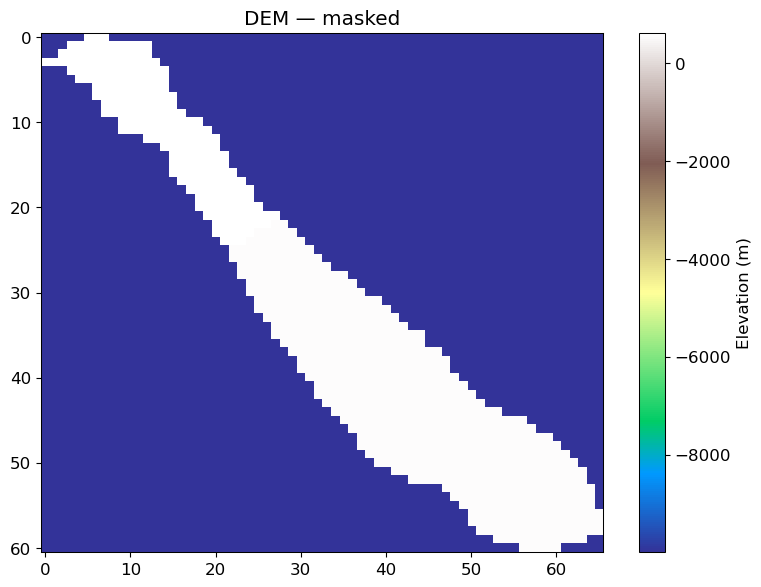

NameError: name 'simu' is not defined

In [9]:
# Feed DEM into CATHY preprocessing inputs
simu.update_prepo_inputs(
    DEM=raster_DEM_masked,
    delta_x=5,   # cell size in x (m)
    delta_y=5,   # cell size in y (m)
    ivert=1,     # invert vertical axis (z positive upward)
)

# Show CATHY's internal DEM representation
simu.show_input(prop="dem")

# 3-D terrain view
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection="3d")
simu.show_input(prop="dem", ax=ax)
plt.tight_layout()
plt.show()

# Write VTK mesh (useful for inspection in ParaView)
simu.create_mesh_vtk(verbose=True)

---
## 11. Run the CATHY Preprocessor

The preprocessor (`run_preprocessor`) performs several mesh-building and domain-setup operations:
- Generates the **3-D finite-element mesh** from the DEM surface
- Computes catchment topology (flow directions, drainage network)
- Produces the `grid3d` structure used in subsequent steps

After the preprocessor finishes we read the 3-D grid back into Python for use when constructing boundary conditions.

In [ ]:
simu.run_preprocessor(verbose=False)

# Read the 3-D mesh outputs
grid3d = simu.read_outputs('grid3d')
print("Grid3D keys:", list(grid3d.keys()))

---
## 12. Build the Atmospheric Boundary Condition (ATMBC) Time Vector

CATHY expects time in **seconds since the start of the simulation**. We convert the ERA5 `valid_time` coordinate (numpy datetime64) to a float array of elapsed seconds.

The **net surface flux** (`netValue`) is the algebraic sum of precipitation and potential evapotranspiration:

$$\text{netValue} = \text{TP} + \text{PEV}$$

Note that PEV values are typically negative (water leaving the soil), so this represents the **net recharge** at each timestep.

In [ ]:
# Reference time (t=0 in the simulation)
t0 = daily_ts['pev'].valid_time[0].values

# Convert datetime axis to seconds elapsed since t0
t_seconds = (daily_ts['pev'].valid_time.values - t0) / np.timedelta64(1, 's')
t_atmbc   = [float(ti) for ti in t_seconds]

# Net surface flux: precipitation + evapotranspiration (PEV is negative)
netValue = np.array(daily_ts['tp']) + np.array(daily_ts['pev'])

print(f"Number of time steps : {len(t_atmbc)}")
print(f"Net flux range       : [{netValue.min():.4f}, {netValue.max():.4f}] m")

---
## 13. Configure Soil Properties (SPP and FP Maps)

CATHY uses two soil property tables:

- **SPP (Soil Physical Properties)** — hydraulic parameters such as saturated hydraulic conductivity (`PERMX/Y/Z`), van Genuchten retention curve parameters, etc. We start from the built-in defaults for a single zone and 15 soil layers.
- **FP (Functional Properties)** — vegetation-related parameters. `ZROOT` (root depth, m) controls how deep transpiration draws moisture from the soil profile.

After setting defaults, `simu.update_soil()` applies `PMIN` — the minimum allowable pressure head, which limits root water uptake under drought stress.

In [ ]:
# ── Soil Physical Properties ─────────────────────────────────────────────────
df_SPP_map = simu.init_soil_SPP_map_df(nzones=1, nstr=15)
SPP_map    = simu.set_SOIL_defaults(SPP_map_default=True)

# Uncomment to override hydraulic conductivity (m/s):
# SPP_map['PERMX'] = 6.88e-4
# SPP_map['PERMY'] = 6.88e-4
# SPP_map['PERMZ'] = 6.88e-4

# ── Functional (Vegetation) Properties ──────────────────────────────────────
simu.update_veg_map()
df_FP_map         = simu.init_soil_FP_map_df(nveg=1)
df_FP_map         = simu.set_SOIL_defaults(FP_map_default=True)
df_FP_map['ZROOT'] = ZROOT   # apply root depth from simulation parameters

# ── Write soil file ──────────────────────────────────────────────────────────
simu.update_soil(PMIN=PMIN, SPP_map=SPP_map)
print(f"Soil updated: PMIN={PMIN} m, ZROOT={ZROOT} m")

---
## 14. Set Initial Conditions

The initial condition specifies the pressure head distribution at t = 0. Key parameters:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `INDP` | 0 | Uniform initial pressure head across the domain |
| `IPOND` | 0 | No ponding at start |
| `pressure_head_ini` | -15 m | Relatively dry initial condition (unsaturated) |

A value of **-15 m** corresponds to moderately dry soil, appropriate for starting a simulation well before the wet season.

In [ ]:
simu.update_ic(
    INDP=0,
    IPOND=0,
    pressure_head_ini=-15   # initial pressure head (m); negative = unsaturated
)
print("Initial conditions set: uniform pressure head = -15 m")

---
## 15. Set Atmospheric Boundary Conditions (ATMBC)

ATMBC is the surface boundary condition that drives the simulation. Parameters:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `HSPATM` | 1 | Spatially uniform surface flux |
| `IETO` | 1 | Use potential ET (PEV) directly as the ET boundary condition |
| `time` | `t_atmbc` | Time axis (seconds since simulation start) |
| `netValue` | TP + PEV | Net surface flux per timestep |

In [ ]:
simu.update_atmbc(
    HSPATM=1,
    IETO=1,
    time=t_atmbc,
    netValue=netValue
)
print(f"ATMBC updated with {len(t_atmbc)} time steps.")

---
## 16. Configure Output and Time-Stepping Parameters

`simu.update_parm()` controls how the processor writes outputs and manages time steps:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `IPRT` | 4 | Output level (4 = write all major output variables) |
| `VTKF` | 0 | Do **not** write per-timestep VTK files (saves disk space) |
| `TIMPRTi` | `t_atmbc` | List of times (s) at which outputs are written — matches forcing timesteps |

In [ ]:
simu.update_parm(
    IPRT=4,
    VTKF=0,          # disable per-step VTK output
    TIMPRTi=t_atmbc  # write outputs at each forcing timestep
)
print("Processor parameters updated.")

---
## 17. Set Boundary Conditions on the Mesh Boundary

CATHY distinguishes three types of mesh boundary condition files:

| File | Description |
|------|-------------|
| `nansfdirbc` | Dirichlet (fixed head) BCs on non-atmospheric non-seepage faces |
| `nansfneubc` | Neumann (fixed flux) BCs on non-atmospheric non-seepage faces |
| `sfbc` | Seepage face BCs |

Setting `no_flow=True` for all lateral and bottom boundaries is the standard **closed-domain** assumption: water can only leave via the surface (atmospheric BC). The boundary condition DataFrame is first built from the mesh nodes and time vector, then each BC type is locked to no-flow.

In [ ]:
# Build the boundary condition DataFrame (one row per node × time combination)
simu.create_mesh_bounds_df(
    'nansfdirbc',
    simu.grid3d["mesh3d_nodes"],
    t_atmbc,
)

print(simu.mesh_bound_cond_df.head())
print("BC columns:", list(simu.mesh_bound_cond_df.columns))

# Apply no-flow to all lateral/bottom boundaries
simu.update_nansfneubc(no_flow=True)
simu.update_nansfdirbc(no_flow=True)
simu.update_sfbc(no_flow=True)

print("Boundary conditions set to no-flow on all non-surface boundaries.")

---
## 18. Run the CATHY Processor (Main Solver)

This is the main computation step. The CATHY processor solves the **Richards equation** for variably-saturated flow in 3-D, advancing the pressure head field through all forcing timesteps.

Key solver parameters:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `IPRT1` | 2 | Iteration-level print verbosity |
| `DTMIN` | 1 × 10⁻² s | Minimum allowed internal time step (ensures convergence during sharp wetting fronts) |
| `DTMAX` | 1 × 10⁴ s | Maximum internal time step (~2.8 hours) |
| `DELTAT` | 1 × 10³ s | Initial trial time step |
| `TRAFLAG` | 0 | Disable solute transport (water flow only) |

> ⚠️ This cell can take several minutes to complete depending on mesh size and simulation period.

In [ ]:
print(f"Running project : {simu.project_name}")
print(f"Work directory  : {simu.workdir}")

simu.run_processor(
    IPRT1=2,
    DTMIN=1e-2,   # minimum internal timestep (s)
    DTMAX=1e4,    # maximum internal timestep (s)
    DELTAT=1e3,   # initial timestep guess (s)
    TRAFLAG=0,    # no solute transport
    verbose=True
)